# Final EDA Summary Template

This notebook is a short shared template for final EDA summaries. Each EDA section has only three parts: research question, features/methods, and main findings.

Use the shared `df` loaded below when possible. If a section needs a different CSV, copy the loading cell inside that section and change the path there.

In [1]:
# Settings for paths to get data
from pathlib import Path
import sys

  # getting the project root
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "summer26-pokemon-battle-predictor" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent


  # finding the data folder
DATA_DIR = PROJECT_ROOT / "data"
  # finding the csv of TRAINING data
PARSED_CSV_PATH = DATA_DIR / "data_cleaned.csv.zip"
  # Adds tools to the system path so we can import the battle module
sys.path.append(str(PROJECT_ROOT / "tools"))
from battle import *
from full_pokemon import *

  # replays
replay_root = DATA_DIR / "replays"
replay_dirs = [
    replay_root / "gen9-randombattle",
    replay_root / "gen9-randombattle_2",
    replay_root / "gen9-randombattle_3",
]

# Settings for data analysis
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
# Load the shared dataframe.
full_df = pd.read_csv(PARSED_CSV_PATH)

# Eliminate any matches where one player quits prematurely
complete_matches = full_df[(full_df['duration'] > 60) & ((full_df["p1_revealed_team_size"] > 2) | (full_df["p2_revealed_team_size"] > 2))]

# only analyze matches for which we know the players' elo ratings (so that we can use elo_diff as a feature)
df = complete_matches[complete_matches['p1elo0'] > 0].copy()
df['elo_diff'] =  df['p1elo0'] - df['p2elo0']
print(df.shape)
df.head()

(11757, 300)


,format,id,p1_win,ratedQ,n_turns,start_time,end_time,duration,p1name,p1side,p1elo0,p1elo1,p2name,p2side,p2elo0,p2elo1,type_diversity_diff,num_boosting_abilities_diff,num_move_boosters_diff,total_stat_diff,p1_total_adv,p1_revealed_team_size,p2_revealed_team_size,M11_name,M11_speciesId,M11_used,M11_gender,M11_shinyQ,M11_level,M11_ability,M11_item,M11_teraType,M11_role,M11_mv1,M11_mv2,M11_mv3,M11_mv4,M11_type1,M11_type2,M11_hp,M11_atk,M11_def,M11_spa,M11_spd,M11_spe,M11_off,M12_name,M12_speciesId,M12_used,M12_gender,...,M24_spd,M24_spe,M24_off,M25_name,M25_speciesId,M25_used,M25_gender,M25_shinyQ,M25_level,M25_ability,M25_item,M25_teraType,M25_role,M25_mv1,M25_mv2,M25_mv3,M25_mv4,M25_type1,M25_type2,M25_hp,M25_atk,M25_def,M25_spa,M25_spd,M25_spe,M25_off,M26_name,M26_speciesId,M26_used,M26_gender,M26_shinyQ,M26_level,M26_ability,M26_item,M26_teraType,M26_role,M26_mv1,M26_mv2,M26_mv3,M26_mv4,M26_type1,M26_type2,M26_hp,M26_atk,M26_def,M26_spa,M26_spd,M26_spe,M26_off,elo_diff
0,gen9randombattle,2642076539,0,True,21,1782884765,1782884937,172,Lirnom,1,1624,1607,Jenome,2,1674,1691,0,0,1,-79,3.125322,4,5,Cyclizar,cyclizar,1,M,False,83,Regenerator,Heavy-Duty Boots,Dragon,Fast Support,taunt,rapidspin,shedtail,dracometeor,Dragon,Normal,252,205,156,189,156,249,205,Cramorant,cramorant,1,M,...,118,158,198,Tsareena,tsareena,1,F,False,87,Queenly Majesty,Life Orb,Steel,Fast Support,tripleaxel,synthesis,highjumpkick,powerwhip,Grass,NaN,267,259,220,137,220,175,259,Toxtricity,toxtricity,1,F,False,82,Punk Rock,Choice Specs,Normal,Fast Attacker,sludgewave,boomburst,voltswitch,overdrive,Electric,Poison,257,165,162,234,162,170,234,-50
3,gen9randombattle,2641831207,1,True,51,1782847154,1782847410,256,soumatou_story,1,2113,2127,TheLastOne,2,2014,2000,-2,-2,2,347,3.903277,6,6,Tsareena,tsareena,1,F,False,87,Queenly Majesty,Choice Scarf,Steel,Fast Support,tripleaxel,knockoff,powerwhip,uturn,Grass,NaN,267,259,220,137,220,175,259,Snorlax,snorlax,1,F,...,179,270,234,Hitmonchan,hitmonchan,1,M,False,87,Iron Fist,Leftovers,Steel,Bulky Support,encore,drainpunch,knockoff,poisonjab,Fighting,NaN,229,232,187,111,241,182,232,Corviknight,corviknight,1,M,False,80,Mirror Armor,Rocky Helmet,Dragon,Bulky Support,uturn,bodypress,bravebird,roost,Flying,Steel,288,185,214,131,182,153,185,99
4,gen9randombattle,2642210572,1,True,18,1782911409,1782911669,260,jobzy,1,1177,1201,danbur,2,1165,1141,0,2,1,-120,1.475808,2,6,Dewgong,dewgong,1,M,False,94,Thick Fat,Assault Vest,Poison,Bulky Attacker,knockoff,tripleaxel,surf,flipturn,Water,Ice,322,185,204,185,232,185,185,Iron Boulder,ironboulder,0,N,...,170,195,256,Jirachi,jirachi,1,N,False,80,Serene Grace,Leftovers,Water,Fast Support,bodyslam,ironhead,protect,wish,Steel,Psychic,291,206,206,206,206,206,206,Kyogre,kyogre,1,N,False,71,Drizzle,Choice Scarf,Water,Fast Attacker,thunder,waterspout,originpulse,icebeam,Water,NaN,259,147,169,254,240,169,254,12
5,gen9randombattle,2642086297,1,True,26,1782886873,1782887142,269,zero16132,1,1901,1920,jnpr010334,2,1956,1937,-1,-2,1,132,2.141758,4,6,Groudon,groudon,1,N,False,72,Drought,Leftovers,Fire,Bulky Setup,stoneedge,swordsdance,heatcrash,precipiceblades,Ground,NaN,263,258,244,186,172,172,258,Arboliva,arboliva,0,F,...,190,211,226,Archaludon,archaludon,1,M,False,78,Stamina,Lum Berry,Ground,Bulky Setup,earthquake,swordsdance,ironhead,outrage,Steel,Dragon,268,209,248,240,146,178,240,Sceptile,sceptile,1,M,False,87,Overgrow,Leftovers,Steel,Fast Support,gigadrain,substitute,focusblast,leechseed,Grass,NaN,264,152,163,232,198,259,232,-55
6,gen9randombattle,2642136946,0,True,50,1782897882,1782898112,230,Alpha Tw,1,2146,2126,forcemajor14,2,2039,2059,-2,-2,-2,-24,-7.592043,5,5,Empoleon,empoleon,1,M,False,84,Competitive,Leftovers,Grass,Bulky Support,roost,icebeam,surf,flipturn,Water,Steel,278,193,196,235,218,149,235,Raging Bolt,ragingbolt,1,N,...,255,163,218,Slowbro,slowbro,1,F,False,85,Regenerator,Leftovers,Fighting,Bulky Setup,scald,irondefense,slackoff,bodypress,Water,Psychic,300,132,236,219,185,100,219,Shiftr

See `data/README.md` for a thorough description of the column headers.

## 1. General Pokemon EDA

### Research Question

-

### Features Looking Into And Methods

Focus: General Pokemon stats, types, and team composition.

-

### Main Findings

-

In [3]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.

# summary_table = ...
# summary_table

## 2. First Pokemon Advantage EDA

### Research Question

- Is the first Pokemon sent out by the players significant enough affect the outcome of the match?

The first Pokemon sent out by the players is random and selected by the game algorithm. If a player sees that this is a bad matchup, they have the option to switch out the Pokemon, relinquishing the ability to use a Pokemon attack that turn. We explore the relations of some features to a player's win rate based on the first Pokemon only to see if they can be used to make a signifcant prediction for the outcome of the match. 

### Features Looking Into And Methods

This is relatively simple, we expore the numeric stats of the first Pokemon on each team along with their categorical types. 

### Main Findings

- It does not seem that differences for the numeric stats of the first Pokemon affect the outcome much. The medians are approximately the same and the distributions visually have the same spread in the boxplots. The correlation of the differences with the outcome are also all smaller than 0.015 in magnitude 
- On the other hand, if we look at the the winrate of the type of Player 1's Pokemon against the type of Player 2's Pokemon, in some instances the ratio is much smaller or larger than 0.5; see the heatmap below

We will proceed by testing a model that takes as input only the elo differential and the first Pokemon's type (note that the elo differential has been studied in other sections).

In [4]:
X = df.copy()

features = ['p1_win',
            'p1elo0', 'M11_hp', 'M11_atk', 'M11_def', 'M11_spa', 'M11_spd', 'M11_spe', 'M11_type1', 'M11_type2',
            'p2elo0', 'M21_hp', 'M21_atk', 'M21_def', 'M21_spa', 'M21_spd', 'M21_spe', 'M21_type1', 'M21_type2']

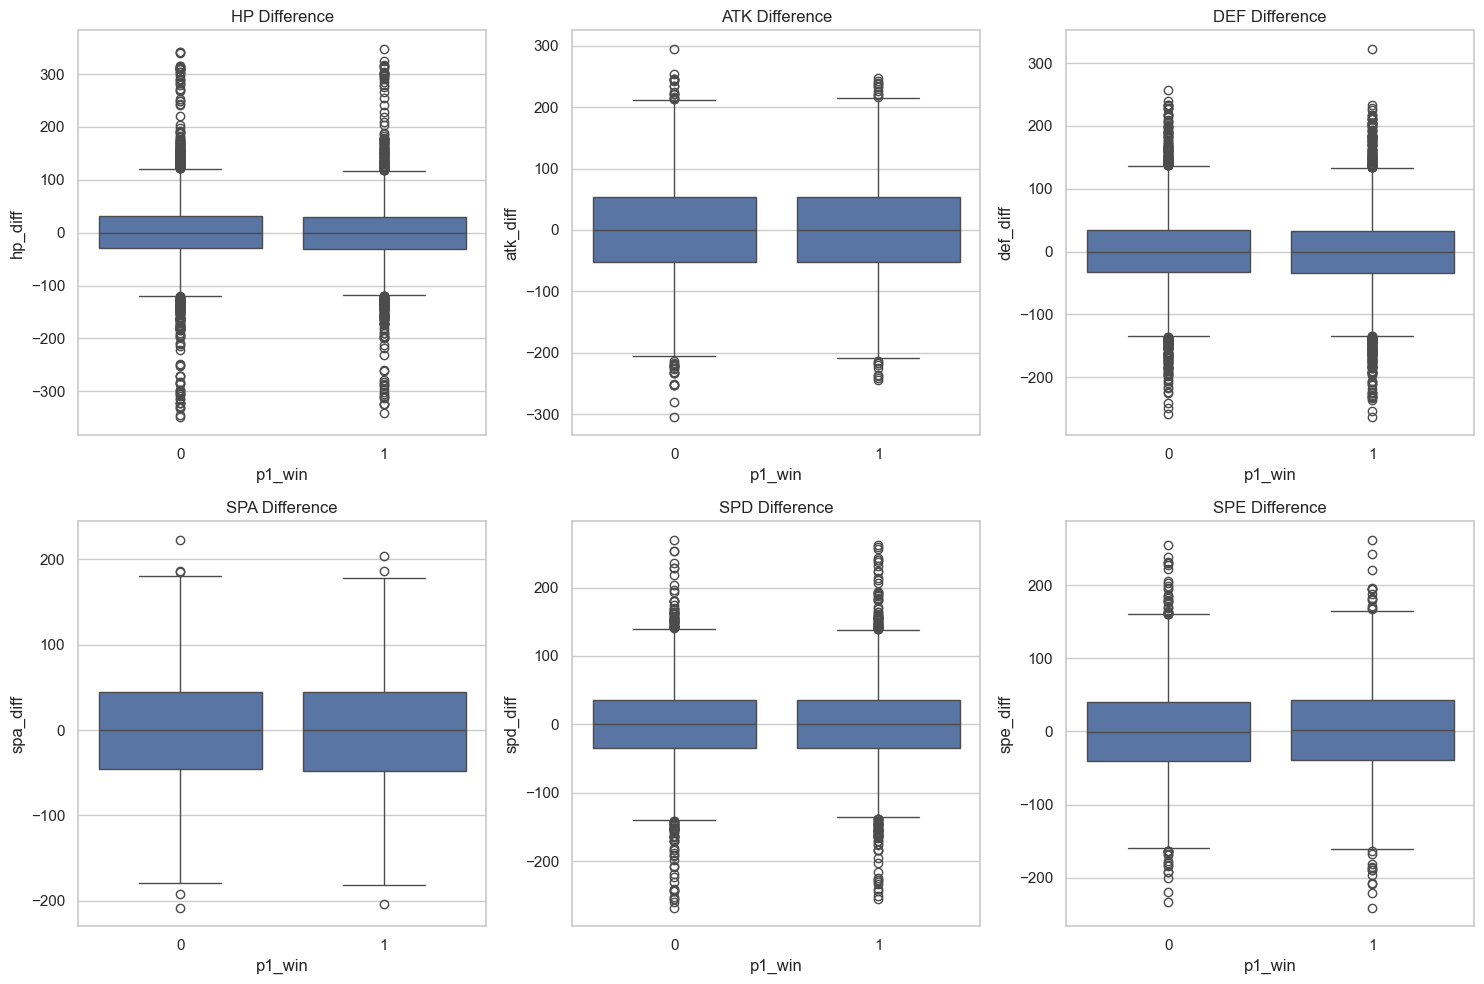

In [5]:
stats = ['hp', 'atk', 'def', 'spa', 'spd', 'spe']

# Calculate differences
for stat in stats:
    X[f'{stat}_diff'] = X[f'M11_{stat}'] - X[f'M21_{stat}']

# Plot differences against win status
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, stat in enumerate(stats):
    sns.boxplot(x='p1_win', y=f'{stat}_diff', data=X, ax=axes[i])
    axes[i].set_title(f'{stat.upper()} Difference')

plt.tight_layout()
plt.show()

In [6]:
# check the correlation of the target with the features
features = []
for stat in stats:
    features.append(f'{stat}_diff')
features.append('p1_win')

print(X[features].corr(numeric_only=True)['p1_win'].sort_values(ascending=False))

p1_win      1.000000
spe_diff    0.018534
spd_diff    0.003600
atk_diff    0.002020
spa_diff   -0.007020
def_diff   -0.011697
hp_diff    -0.014076
Name: p1_win, dtype: float64


In [7]:
# check p1 win rate
print(X['p1_win'].mean())

0.47622692863825805


In [8]:
# check the win rate by type of p1' pokemon
X.groupby('M11_type1')['p1_win'].mean()

M11_type1
Bug         0.473186
Dark        0.441429
Dragon      0.462891
Electric    0.487691
Fairy       0.495268
Fighting    0.503546
Fire        0.483176
Flying      0.470968
Ghost       0.467706
Grass       0.472518
Ground      0.488372
Ice         0.449210
Normal      0.479582
Poison      0.486000
Psychic     0.437936
Rock        0.481273
Steel       0.461690
Water       0.500699
Name: p1_win, dtype: float64

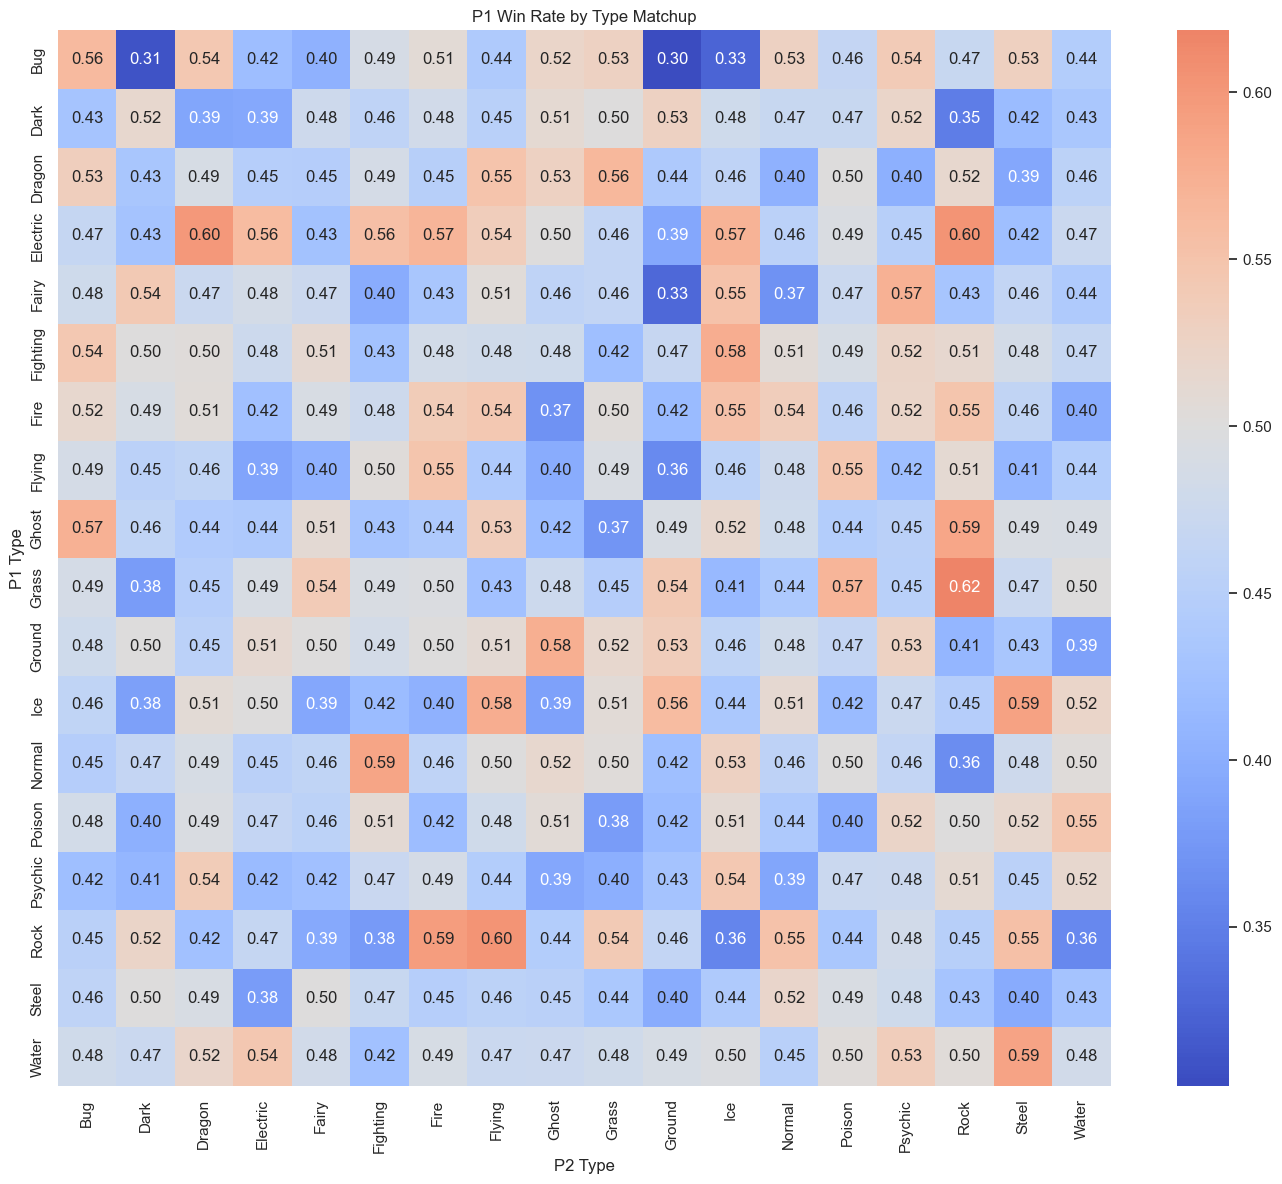

In [9]:
# In the heatmap below, we find the winrate of P1's pokemon against P2's pokemon based on their types
# Note, for example, if P1's pokemon has two types, and P2's pokemon has two types, we will count all four combinations of types in the winrate calculation

# Combine P1 and P2 types into lists, removing missing values
X['p1_types'] = X[['M11_type1', 'M11_type2']].values.tolist()
X['p2_types'] = X[['M21_type1', 'M21_type2']].values.tolist()

X['p1_types'] = X['p1_types'].apply(lambda x: [t for t in x if pd.notna(t) and t != 'None'])
X['p2_types'] = X['p2_types'].apply(lambda x: [t for t in x if pd.notna(t) and t != 'None'])

# Explode to get all combinations of P1 types vs P2 types per match
exploded_X = X.explode('p1_types').explode('p2_types')

# Calculate win rates and pivot into a matrix
win_matrix = exploded_X.groupby(['p1_types', 'p2_types'])['p1_win'].mean().unstack()

# Plot the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(win_matrix, cmap='coolwarm', annot=True, fmt=".2f", center=0.5)
plt.title('P1 Win Rate by Type Matchup')
plt.ylabel('P1 Type')
plt.xlabel('P2 Type')
plt.tight_layout()
plt.show()

## 3. Active Switch Count And Win Rate EDA

### Research Question

- Switching out an active Pokemon essentially forfeits a turn during a Pokemon battle. With this in mind, does a higher switch rate decrease the probability of a win? Does switching in the first turn before making a move affect probability of a win?

### Features Considered

Focus: Relationship between active switches during battle and win rate.

### Main Findings

- Lowest-rated players tend to switch less
- Overall switch rate doesn't significantly affect win rate
- Switching in the first turn is a slight disadvantage

In [10]:
# Function for getting stats about player switches
def get_switch_stats(battle):
    '''
    Gets following stats from Pokemon showdown logs:

    - turns
        Number of turns in the battle
    - <player>_switches
        Total number of player switches excluding lead Pokemon and fainting
    - <player>_switched_early
        Flags whether a player swapped their lead Pokemon on turn 1 before making a move
    '''

    # Ignore the first "switch" that is actually just the lead pokemon
    p1_switches = -1
    p2_switches = -1

    p1_seen_move = False
    p2_seen_move = False

    p1_switched_early = 0
    p2_switched_early = 0

    # Flag that says whether the pokemon has fainted and needs replacement
    p1_needs_replacement = False
    p2_needs_replacement = False

    turns = 0

    for line in battle.log.split("\n"):
        #print(line)
        # Trying to ignore switches caused by fainting
        if line.startswith("|faint|"):
            if "|p1" in line:
                p1_needs_replacement = True

            elif "|p2" in line:
                p2_needs_replacement = True

        # increment nummber of turns
        #if line.startswith("|turn|"):
        #    turns = int(line.split("|")[2])

        fields = line.split("|")

        if len(fields) < 3:
            continue

        if line.startswith("|move|"):
            #print(line)

            slot = fields[2]

            if slot.startswith("p1"):
                p1_seen_move = True

            elif slot.startswith("p2"):
                p2_seen_move = True
                
        elif line.startswith("|switch|"):

            slot = fields[2]

            if slot.startswith("p1"):

                if not p1_needs_replacement:
                    p1_switches += 1

                p1_needs_replacement = False

                if not p1_seen_move and p1_switches > 0:
                    p1_switched_early = 1

            elif slot.startswith("p2"):

                if not p2_needs_replacement:
                    p2_switches += 1

                p2_needs_replacement = False

                if not p2_seen_move and p2_switches > 0:
                    p2_switched_early = 1
                    
    return {
        #"turns": turns,
        "p1_switches": p1_switches,
        "p2_switches": p2_switches,
        "p1_switched_early": p1_switched_early,
        "p2_switched_early": p2_switched_early
    }

In [11]:
files = []
for replay_dir in replay_dirs:
    files.extend(sorted(replay_dir.glob("*.json")))

print(f"There are {len(files)} replay files")

rows = []

for file in files:

    try:
        battle = Battle(file)
    except Exception:
        continue

    stats = get_switch_stats(battle)
    rows.append({"id": battle.id, **stats})

# Create dataframe with the output of get_switch_stats
switch_df = pd.DataFrame(rows)

# remove string at the beginning of the battle id
switch_df["id"] = (
    switch_df["id"]
    .str.replace("gen9randombattle-", "", regex=False)
    .astype(int)
)

# Merge main dataframe with switched stats dataframe
merged_df = df.merge(switch_df, on="id", how="left")

There are 12778 replay files


Text(0.5, 1.0, 'Early Switching vs Win Rate')

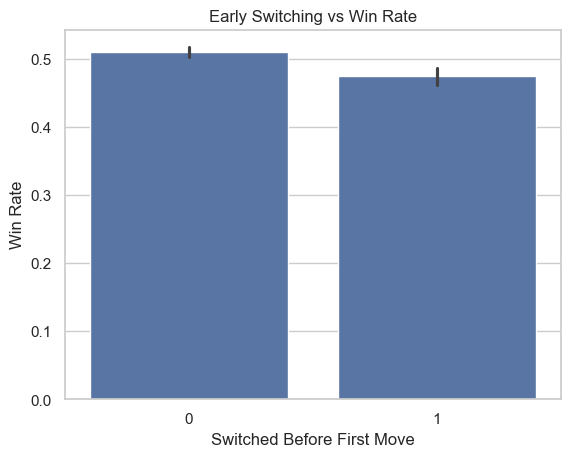

In [12]:
# Early switching versus win rate
# Look at all players regardless of battle id
early_df = pd.DataFrame({
    "switched_early": pd.concat([
        merged_df["p1_switched_early"],
        merged_df["p2_switched_early"]
    ]),
    "won": pd.concat([
        merged_df["p1_win"],
        1 - merged_df["p1_win"]
    ])
})

sns.barplot(data=early_df, x="switched_early", y="won")

plt.xlabel("Switched Before First Move")
plt.ylabel("Win Rate")
plt.title("Early Switching vs Win Rate")

Switched Before First Move
  -  0 if False
  -  1 if True

The win rate is a bit above 0.5 if the player did not switch before the first move. This is a slightly higher win rate than players who did switch before the first move, suggesting that forfeiting the first turn by swapping the lead Pokemon may be a disadvantage. 

On the other hand, experienced players may recognize a disadvantage (either in Pokemon type, species, or some other stats-based disadvantage) in their first matchup and switch out the lead Pokemon in response to the disadvantage, meaning that this pattern is more about correlation than causation.

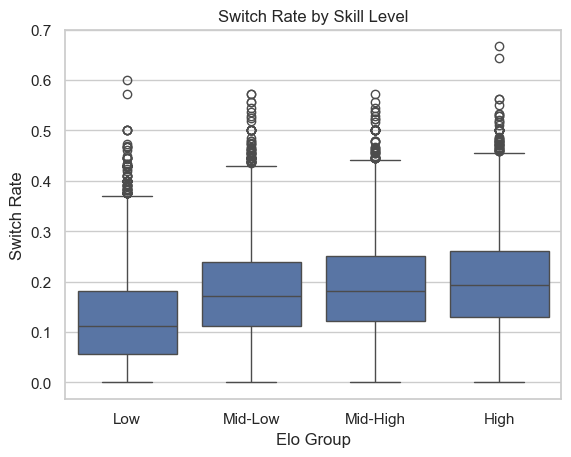

In [13]:
# Switching by elo
# create a dataframe with each player having their own row
player_df = pd.DataFrame({

    "elo": pd.concat([
        merged_df["p1elo0"],
        merged_df["p2elo0"]
    ]),

    "switches": pd.concat([
        merged_df["p1_switches"],
        merged_df["p2_switches"]
    ]),

    "turns": pd.concat([
        merged_df["n_turns"],
        merged_df["n_turns"]
    ]),

    "switch_rate": pd.concat([
        merged_df["p1_switches"] / merged_df["n_turns"],
        merged_df["p2_switches"] / merged_df["n_turns"]
    ]),

    "won": pd.concat([
        merged_df["p1_win"],
        1 - merged_df["p1_win"]
    ])
})

# separate elo score groups into 4 different bins
player_df["elo_group"] = pd.qcut(
    player_df["elo"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# Total number of switches by elo score 
#sns.boxplot(data=player_df, x="elo_group", y="switches")

#plt.xlabel("Elo Group")
#plt.ylabel("Number of Switches")
#plt.title("Switching Frequency by Skill Level")
#plt.show()
boxplot_colors = ["#2976bb", "#e17701", "#77ab56", "#bb3f3f"]
# Switch rate by elo
sns.boxplot(data=player_df, x="elo_group", y="switch_rate")

plt.xlabel("Elo Group")
plt.ylabel("Switch Rate")
plt.title("Switch Rate by Skill Level")
plt.show()

switch_rate = $\frac{total\ number\ of\ player\ switches}{number\ of\ turns}$

Elo score is a way of quantifying a player's skill level. It can be assumed that players with a higher elo score would therefore have a better intuition for when it is advantageous to swap their Pokemon and may be a more reliable predictor of win rate.

The above box plot shows that the lowest-rated players swap their Pokemon noticably less than other players. The switch rate appears to level off starting with mid-high elo scores. 

In [14]:
print(f"The Elo threshold to be rated mid-high is: {player_df["elo"].quantile(0.5)}")

The Elo threshold to be rated mid-high is: 1965.0


Since the switch rate is stable in the mid-high and high categories, we conclude that those players are using optimal switching strategies.  Since our EDA would benefit from an assumption that players are using uniform strategies, we conduct our remaining EDA on battles where each player has a minimum rating of 1965.

Text(0.5, 1.0, 'Win Rate vs Switch Rate')

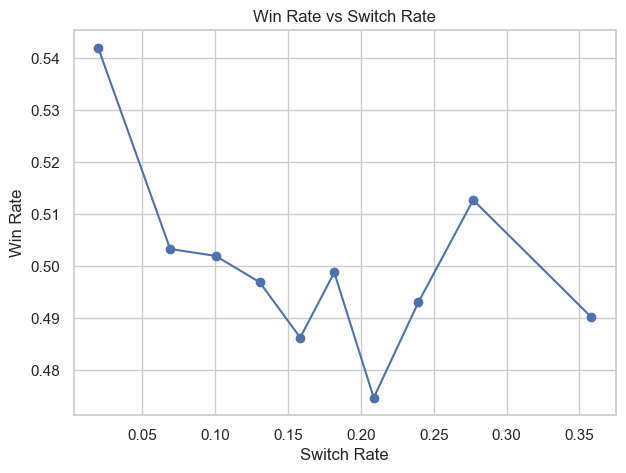

In [15]:
# Win rate versus switch rate
# Bin switch_rate into groups for plotting
player_df["switch_bin"] = pd.qcut(player_df["switch_rate"], 10, duplicates="drop")

summary = (
    player_df
    .groupby("switch_bin", observed=True)
    .agg(
        mean_switch=("switch_rate", "mean"),
        win_rate=("won", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(7,5))

plt.plot(
    summary["mean_switch"],
    summary["win_rate"],
    marker="o"
)

plt.xlabel("Switch Rate")
plt.ylabel("Win Rate")
plt.title("Win Rate vs Switch Rate")

## 4. Pokemon Advantage Stats EDA

### Research Question

- Can we teach the model about individual pokemon interactions (e.g. 'water beats fire' and 'a large defense stat is good against physical attackers but useless against special attackers') without requiring it to learn those interactions from team-level data (e.g. this team of six pokemon beat this other team of six pokemon)?

This question carries major significance for our project.  After all, an experienced Pokemon player is able to rapidly analyze individual matchups and uses that information to inform their strategies.  Our final model should be able to use the same information the players are using.  The primary subquestion is then:

  - What information are the players using to make decisions during a battle?

#### Example

As an instructive example of the kind of analysis that an experienced player typically does, consider a hypothetical matchup of Tauros-Paldea-Aqua against Delphox.

##### Major factors

<u>Type</u>

Tauros is a Fighting-Water type while Delphox is Fire-Psychic.  If Tauros uses a water move into Delphox, it will be supereffective (i.e. the damage dealt to the Delphox will be multiplied by 2), while if Delphox uses a Psychic move into Tauros, it will also be supereffective.  With only information about the types of the two Pokemon, it's hard to say who has the advantage.

<u>Statistics</u>

Let's next look at the statistics of these two Pokemon.  Neither Pokemon here is the most powerful attacker.  Delphox uses special attacks, and its special attack stat is 240, which is average to below average for a special attacker.  Tauros uses physical attacks, and its attack stat is 225, which is below average for a physical attacker.  Their respective defensive stats are also somewhat low: Tauros' special defense stat is 160, and Delphox's defense stat is 169.  Their HP stats are again, quite similar with the Delphox having 263 hit points and the Tauros having 254 hit points.  Finally, Delphox is the faster of the two Pokemon, so it gets to move first every round.

Given all of this information, it seems like the Delphox has the advantage: the Delphox gets to move first, and the amount of damage each is doing to the other should be fairly comparable.  Without any more information, an experienced player might guess that in a one-on-one matchup between these two Pokemon, the Delpox will knock out the Tauros after two rounds of combat.  This is only a modest advantage however, since there are situations where the Tauros could beat the Delphox.  For instance, if the Tauros begins the one-on-one matchup with full HP and the Delphox enters the matchup with only half of its HP, the Tauros will take lots of damage from the Delphox's attack, but will KO the Delphox in response.

##### Minor Factors

That said, there are other factors at play here, like which items the Pokemon are holding, or which abilities they have.

<u>Abilities</u>

Different Pokemon have different special abilities which can alter matchups.  Neither Pokemon's ability is relevant to this particular matchup.

<u>Items</u>

Delphox sometimes carries the Choice Specs item in this format which boosts its special attack stat to well-above average levels.  Tauros often carries the Choice Band item, which has the analogous effect for its stats.

If the Delphox has Choice Specs, it now dominates the Tauros: it moves first, and KOs the Tauros before the Tauros can do anything in return.  If the Delphox does not have Choice Specs, while the Tauros has a Choice Band, the Tauros now has a small advantage: in the first round of combat, the Tauros takes lots of damage from the Delphox, but manages to KO the Delphox on its turn.

<u>Known Moves</u>

The analysis up to this point has been assuming that Tauros knows a generic water move and Delphox knows a generic psychic move, but what if their moves aren't generic?  If the Tauros knows Wave Crash (a very powerful water move that deals recoil damage to the Tauros), then the matchup may end up with both pokemon being knocked out as the Delphox first deals damage to the Tauros, and the Tauros responds with Wave Crash, knocking out the Delphox, and then knocking out the Tauros with the recoil damage.  Alternatively, if the Tauros knows a less powerful water move without the recoil (say, Liquidation), but the Tauros also knows Aqua Jet (a water move without much power, but which allows the Tauros to go before the Delphox), its possible that the Tauros could knock out Delphox in the second round of combat.

##### Conclusion

If our model trains on a data set that only contains the 12 pokemon involved in a battle, their types, abilities, items, known moves (all represented by strings so far), and stats (represented by ints), the model is unlikely to learn the feature interactions that players use all of the time.  Indeed, it might only ever see one match in which Tauros-Paldea-Aqua is on one team and Delphox is on the other, and in that match, it will only see which team won.  Instead, we need to find some way of telling the model the information that we already know about how these features interact.

### Features Considered

In order to account for the matchups of individual pokemon, we created the advantage statistic, which measures how big of an advantage one Pokemon has over the other.  Advantage is a damage-based statistic.

Given two Pokemon, say Tauros-Paldea-Aqua and Delphox, the advantage statistic starts by approximating how much damage each Pokemon would deal to the other with its best single generic attack (as a proportion of the defending Pokemon's HP).  For instance, it will calculate how much average damage Delphox will do to Tauros with a generic Psychic attack (let's say 80%) and how much damage Tauros will do to Delphox with a generic Water attack (let's say 70%).

From those numbers, it will "simulate" a one-on-one matchup between those two Pokemon, with each Pokemon assumed to only select its best damaging move.  With the numbers above, on the first turn, Delphox deals 80% damage to Tauros, while Tauros deals 70% damage to Delphox.  On the next turn, Delphox KOs Tauros and Tauros does not get to deal any more damage.

The advantage statistic is the damage differential in given matchup.  In the above example, Delphox deals damage equal to 2*80% = 160% of Tauros' HP, while Tauros deals damage equal to 70% of Delphox's HP.  Then advantage(Delphox,Tauros) = 160% - 70% = 90%, while advantage(Tauros,Delphox) = 70% - 160% = -90%.

In a battle, then, where each team has 6 pokemon, we computed the 36 distinct (up to sign) advantage stats of the form advantage(m1,m2) where m1 is a Pokemon on team 1 and m2 is a Pokemon on team 2.  The total advantage of player 1 is defined to be the sum of those 36 advantage stats.

Note: why train on the 1-dimensional total advantage stat rather than the 36-dimensional list of advantage stats?  The primary reason is that we know that across all battles, each matchup should carry the same weight.  While it might be true for a particular match that Player 1 Pokemon 3's advantage over Player 2 Pokemon 5 means more than Player 1 Pokemon 4's advantage over Player 2 Pokemon 1, those two matchups should carry the same weight across all battles.  (It's also worth noting that models which trained on total advantage performed better than those that trained on the 36 individual stats.)

### Known Limitations

There are a number of limitations to the advantage stat.

First and foremost, the advantage stat uses a damage approximation.  We have the exact formula for damage calculations, but it is incredibly complex to implement due to the vast array of moves, abilities, items, and field conditions.  While our damage calculator accounts for the major factors listed above (types and stats), it handles only some abilities and a few of the most common items.  It does not attempt to account for moves in any way.  The best way to improve upon this would be to learn to access the calculator at calc.pokemonshowdown.com.

Second, the advantage stat fails to account for mixed attackers.  Some few pokemon (like Iron Valiant) use both physical and special attacks in order to counter opponents who they might otherwise have trouble with.  The advantage stat pretends that each pokemon only uses one category of attack.  Again, this would be corrected by using the damage calculator at calc.pokemonshowdown.com.

Perhaps more subtle is the issue that our advantage stat makes an assumption that each individual Pokemon enters the matchup with full HP.  This tends to punish sweepers/fast wallbreakers like the offensive Deoxys variants who can deal 90% damage to nearly any pokemon, but get knocked out by nearly any attack.  Perhaps we could improve upon this by adjusting the advantage stat so that it depends on current HP rather than maximum HP.  Then, at the beginning of the battle we could take the average of all advantage stats across all HP states (or a substantial selection of them depending on computational complexity).


### Ad Hoc Corrections

In an attempt to correct for some of the limitations of the advantage stat, we created some variables which count the number of Pokemon that the advantage statistic might underrate.  For example, our damage approximator does not attempt to account for abilities which boost statistics if certain conditions are met (like Blaze) or moves which change a Pokemon's stats (like Dragon Dance or Trailblaze).  For brevity, we will not list the full selection of features that we considered, but here are a few examples:

- Number of trappers (i.e. Pokemon whose ability can prevent their foe from switching out)
- Number of Pokemon whose ability grants them immunities to certain types of damage
- Number of Pokemon whose ability boosts their statistics under certain conditions
- Number of Pokemon which know a move that boosts their own stats

We counted the number of Pokemon meeting these conditions on each team, then analyzed the differential of these counts (e.g. number of trappers on team 1 minus the number of trappers on team 2).

### Main Findings

- Player 1's total advantage stat has the strongest correlation to winning out of all of the other features we explored, followed closely by Elo differential.
- There were no ad hoc features that have meaningful correlations to winning.

The first thing we need to do is collect all of the features.  We did not put every explored feature in the csv used to generate `df`, so we'll construct a new dataframe first.

In [16]:
# The list of traits and the method names in FullPokemon which return True if and only if the Pokemon has the desired trait
trait_method_map = {
        "trappers": "is_trapper",
        "type_changers": "is_type_changer",
        "weather_setters": "is_weather_setter",
        "terrain_setters": "is_terrain_setter",
        "stat_drop_resistors": "is_stat_drop_resistor",
        "absorbers": "is_absorber",
        "extra_immunities": "has_extra_immunities",
        "status_resists": "is_status_resistor",
        "contact_punishers": "is_contact_punisher",
        "ability_ignorers": "is_ability_ignorer",
        "pranksters": lambda mon: mon.ability == "Prankster",
        "intimidators": lambda mon: mon.ability == "Intimidate",
        "unaware": lambda mon: mon.ability == "Unaware",
        "harvest": lambda mon: mon.ability == "Harvest",
        "regenerators": lambda mon: mon.ability == "Regenerator",
        "serene_grace": lambda mon: mon.ability == "Serene Grace",
        "sturdy": lambda mon: mon.ability == "Sturdy",
        "illusion": lambda mon: mon.ability == "Illusion",
        "triage": lambda mon: mon.ability == "Triage",
        "boosting_abilities": "has_boosting_ability",
        "weather_boosters": "is_weather_booster",
        "omni_boosters": "has_omni_boost",
        "off_def_spe_boosters": "has_off_def_spe_boost",
        "off_spe_boosters": "has_off_spe_boost",
        "off_def_boosters": "has_off_def_boost",
        "off_boosters": "has_off_boost",
        "spe_boosters": "has_spe_boost",
        "def_boosters": "has_def_boost",
        "move_boosters": "has_boost_move",
}

traits = trait_method_map.keys()

# Given a trait and a team of Pokemon, returns the number of Pokemon on that team with the trait
def count_trait(team, trait):
        method = trait_method_map[trait]
        if isinstance(method, str):
                return sum(int(getattr(mon, method)()) for mon in team)
        return sum(int(method(mon)) for mon in team)

In [17]:
log_dir_1 = Path("../data/replays/gen9-randombattle")
log_dir_2 = Path("../data/replays/gen9-randombattle_2")
log_dir_3 = Path("../data/replays/gen9-randombattle_3")
log_dirs = [log_dir_1,log_dir_2,log_dir_3]
stat_names = ['hp','atk','def','spa','spd','spe']
red_stat_names = ['hp','off','def','spd','spe'] # reduced stat names where off stands in for max(atk,spa)

rows = []
for log_dir in log_dirs:
    for file in log_dir.iterdir():
        if file.is_file():
            battle = Battle(file,parse=True)
            if not battle.custom_ruleQ: # throw out battles with custom rules
                to_add = {
                    "id": battle.id,
                    "rated": battle.rated,
                    "duration": battle.end_time - battle.start_time,
                    "p1": battle.players[0],
                    "p2": battle.players[1],
                    "p1_rating" : battle.player_dets[0]["rating"],
                    "elo_diff": battle.player_dets[0]["rating"] - battle.player_dets[1]["rating"],
                    "p1_wins" : battle.players[0] == battle.winner.name,
                    "p1_revealed_team_size" : len(battle.teams[0].keys()),
                    "p2_revealed_team_size" : len(battle.teams[1].keys()),
                }
                # Team construction
                team1 = [FullPokemon(battle.teams_full[0][mon]) for mon in battle.teams_full[0].keys()]
                team2 = [FullPokemon(battle.teams_full[1][mon]) for mon in battle.teams_full[1].keys()]
                teams = [team1,team2]

                # type_diversity_diff
                p1_types = set(mon.types[i] for mon in team1 for i in range(len(mon.types)))
                p2_types = set(mon.types[i] for mon in team2 for i in range(len(mon.types)))
                to_add["type_diversity_diff"] = len(p1_types) - len(p2_types)

                # total_stat_diff
                p1_total_stats = sum(sum(mon.stats[stat] for stat in red_stat_names) for mon in team1)
                p2_total_stats = sum(sum(mon.stats[stat] for stat in red_stat_names) for mon in team2)
                to_add["total_stat_diff"] = p1_total_stats - p2_total_stats

                # total advantage
                to_add["p1_total_adv"] = sum(FullPokemon.advantage(team1[m1],team2[m2]) for m1 in range(6) for m2 in range(6))

                # trait diffs
                for trait in traits:
                    p1_num_trait = count_trait(team1, trait)
                    p2_num_trait = count_trait(team2, trait)
                    to_add[f"num_{trait}_diff"] = p1_num_trait - p2_num_trait

                rows.append(to_add)

# contains all information about all relevant matches in our data set
full_match_data = pd.DataFrame(rows)

ss = StandardScaler()
copy = copy.deepcopy(full_match_data)
full_match_data['normalized_elo_diff'] = ss.fit_transform(copy[['elo_diff']])
full_match_data['normalized_adv'] = ss.fit_transform(copy[['p1_total_adv']])

In [18]:
# We should throw away matches where people rage quit early
complete_matches = full_match_data[(full_match_data['duration'] > 60) & ((full_match_data["p1_revealed_team_size"] > 2) | (full_match_data["p2_revealed_team_size"] > 2))]
# This is to grab matches where we know that the players understand the basic switching strategy (from Marz' work on switching)
threshold = 1965
highly_rated_matches = complete_matches[(complete_matches['p1_rating'] > threshold) & (complete_matches[['p1_rating','elo_diff']].sum(axis=1) > threshold)]

In [19]:
# Let's check the p-values of each individual feature in a logistic regression
features = [f"num_{trait}_diff" for trait in traits] + ['normalized_adv', 'normalized_elo_diff','type_diversity_diff','total_stat_diff']

models = [sm.Logit(highly_rated_matches['p1_wins'],highly_rated_matches[[feature]],offset=0).fit(disp=False) for feature in features]

rows = []
for i in range(len(features)):
    summary = pd.Series({"feature" : features[i], "p-value" : models[i].pvalues.iloc[0], "coefficient" : models[i].params.iloc[0]})
    rows.append(summary)

table = pd.DataFrame(rows)
table.sort_values("p-value",ascending=True)

,feature,p-value,coefficient
29,normalized_adv,7.124808e-07,0.143459
30,normalized_elo_diff,9.414981e-04,0.084737
19,num_boosting_abilities_diff,2.016638e-01,0.022817
9,num_ability_ignorers_diff,2.538718e-01,-0.081483
20,num_weather_boosters_diff,3.204016e-01,-0.049400
8,num_contact_punishers_diff,3.329029e-01,0.046908
5,num_absorbers_diff,3.382057e-01,-0.030588
0,num_trappers_diff,3.659075e-01,0.090983
21,num_omni_boosters_diff,4.447649e-01,0.106386
3,num_terrain_setters_diff,4.726661e-01,0.057346


Of all of the features we explored, the only two with clear impact on the outcome of the match are Elo differential and advantage.

Since Elo differential and advantage are independent (more or less by construction), we'll add them both the the logistic regression, and we'll see if any of the other traits contribute to that model.

In [20]:
features = [f"num_{trait}_diff" for trait in traits] + ['type_diversity_diff','total_stat_diff']

models = [sm.Logit(highly_rated_matches['p1_wins'],highly_rated_matches[['normalized_elo_diff','normalized_adv',feature]],offset=0).fit(disp=False) for feature in features]

rows = []
for i in range(len(features)):
    summary = pd.Series({"feature" : features[i], "p-value" : models[i].pvalues.iloc[2], "coefficient" : models[i].params.iloc[2]})
    rows.append(summary)

table = pd.DataFrame(rows)
table.sort_values("p-value",ascending=True)

,feature,p-value,coefficient
19,num_boosting_abilities_diff,0.188394,0.023601
22,num_off_def_spe_boosters_diff,0.197181,0.073559
5,num_absorbers_diff,0.198055,-0.041359
30,total_stat_diff,0.224559,-0.000172
9,num_ability_ignorers_diff,0.229395,-0.086166
20,num_weather_boosters_diff,0.276364,-0.054361
8,num_contact_punishers_diff,0.319721,0.048388
21,num_omni_boosters_diff,0.337868,0.134045
23,num_off_spe_boosters_diff,0.357872,0.028206
28,num_move_boosters_diff,0.369045,0.015469


Nothing is really standing out here.  These extra traits don't carry much explanatory power.

It's worth noting that after some fiddling, we can make small improvements to the predictive cross-validation performance of various models by adding a couple of these features (notably, the differential in the number of Pokemon in boosting moves and situational boosting abilities).